# Does a larger calibration set improve CIFAR-100 SDM reliability?

This notebook runs the held-out experiment that notebook 03 prepares. It compares two **nested calibration sets** on the same seed-42 ConvNeXt-Tiny model:

| Track | Calibration size | Images/class |
|---|---:|---:|
| `standard_25` | 2,500 | 25 |
| `enlarged_100` | 10,000 | 100 |

The model, 37,500-image training/reference support, 2,500-image validation set, and 10,000-image official test set are identical for both tracks. The standard set is a subset of the enlarged set. This isolates the effect of calibration sample size; no calibration or test image appears in model training.

The notebook retains per-image results and adds aggregate reliability metrics: NLL, Brier score, ECE, error-detection AUROC/AUPRC, risk–coverage curves, AURC, coverage at 95% selective accuracy, fixed-coverage accuracy, High-Reliability (HR) coverage/accuracy, and cohort breakdowns.

> Full experiment: run normally. Pipeline check: start Jupyter with `SDM_RUN_MODE=smoke`. Smoke results are incomplete and must not be interpreted.

## Experimental rules

1. Train with cross-entropy and ordinary softmax; select the checkpoint only on validation accuracy.
2. Fit every SDM empirical CDF, threshold, and class cohort on calibration data.
3. Freeze both tracks before loading the official test set.
4. Evaluate both tracks once on exactly the same test images.
5. Do not tune choices from test outcomes.

The checkpoint has a distinct run directory from notebooks 02–03 because the 100/class calibration design reduces training support from 450 to 375 images/class.

In [1]:
from __future__ import annotations

import json
import os
import platform
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny
from torchvision.transforms import InterpolationMode

RUN_MODE = os.environ.get("SDM_RUN_MODE", "benchmark").strip().lower()
if RUN_MODE not in {"benchmark", "smoke"}:
    raise ValueError("SDM_RUN_MODE must be 'benchmark' or 'smoke'.")

SEED = 42
TARGET_ALPHA = 0.95
MODEL_NAME = "convnext_tiny_imagenet1k_v1"
EXPERIMENT_NAME = "calibration_25_vs_100"
DATA_DIR = Path(os.environ.get(
    "SDM_DATA_DIR", Path.home() / ".cache" / "sdm-vision-reliability"
)).expanduser()
RUN_DIR = Path(os.environ.get(
    "SDM_RUN_DIR",
    DATA_DIR / "runs" / MODEL_NAME / f"seed_{SEED}" / EXPERIMENT_NAME / RUN_MODE,
)).expanduser()
DATA_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

SMOKE = RUN_MODE == "smoke"
IMAGE_SIZE = 224
BATCH_SIZE = 8 if SMOKE else 128
EPOCHS = 1 if SMOKE else 20
MAX_TRAIN_BATCHES = 2 if SMOKE else None
MAX_EXPORT_BATCHES = 2 if SMOKE else None
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
NUM_WORKERS = 0 if platform.system() in {"Windows", "Darwin"} else min(4, os.cpu_count() or 1)
FORCE_RETRAIN = os.environ.get("SDM_FORCE_RETRAIN", "0") == "1"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
USE_AMP = DEVICE.type == "cuda"

CONFIG = {
    "run_mode": RUN_MODE,
    "seed": SEED,
    "target_alpha": TARGET_ALPHA,
    "model_name": MODEL_NAME,
    "experiment_name": EXPERIMENT_NAME,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "device": str(DEVICE),
    "calibration_images_per_class": [25, 100],
}
print(json.dumps(CONFIG, indent=2))
print(f"Outputs: {RUN_DIR}")

{
  "run_mode": "benchmark",
  "seed": 42,
  "target_alpha": 0.95,
  "model_name": "convnext_tiny_imagenet1k_v1",
  "experiment_name": "calibration_25_vs_100",
  "image_size": 224,
  "batch_size": 128,
  "epochs": 20,
  "learning_rate": 0.0003,
  "weight_decay": 0.05,
  "label_smoothing": 0.1,
  "device": "cuda",
  "calibration_images_per_class": [
    25,
    100
  ]
}
Outputs: /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/calibration_25_vs_100/benchmark


## Reproducibility: every stochastic source uses seed 42

In [2]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


seed_everything(SEED)

## Build one leakage-free split for both calibration tracks

Within each CIFAR-100 class, the seed-42 permutation assigns 25 images to validation, the next 100 to the enlarged calibration pool, and 375 to training/reference support. `standard_25` uses the first 25 images of that calibration pool. Nesting removes split-composition noise from the 25-versus-100 comparison.

In [3]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.65, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25),
])
eval_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_aug_base = datasets.CIFAR100(DATA_DIR, train=True, download=True, transform=train_transform)
train_eval_base = datasets.CIFAR100(DATA_DIR, train=True, download=False, transform=eval_transform)
targets = np.asarray(train_aug_base.targets)
rng = np.random.default_rng(SEED)
train_indices, validation_indices, calibration_25_indices, calibration_100_indices = [], [], [], []

for class_id in range(100):
    class_indices = rng.permutation(np.flatnonzero(targets == class_id))
    validation_indices.extend(class_indices[:25])
    calibration_100_indices.extend(class_indices[25:125])
    calibration_25_indices.extend(class_indices[25:50])
    train_indices.extend(class_indices[125:])

train_indices = np.asarray(train_indices)
validation_indices = np.asarray(validation_indices)
calibration_25_indices = np.asarray(calibration_25_indices)
calibration_100_indices = np.asarray(calibration_100_indices)

assert len(train_indices) == 37_500
assert len(validation_indices) == 2_500
assert len(calibration_25_indices) == 2_500
assert len(calibration_100_indices) == 10_000
assert set(calibration_25_indices) <= set(calibration_100_indices)
assert not set(train_indices) & set(validation_indices)
assert not set(train_indices) & set(calibration_100_indices)
assert not set(validation_indices) & set(calibration_100_indices)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
}
train_loader = DataLoader(
    Subset(train_aug_base, train_indices), shuffle=True,
    generator=torch.Generator().manual_seed(SEED), **loader_options
)
reference_loader = DataLoader(Subset(train_eval_base, train_indices), shuffle=False, **loader_options)
validation_loader = DataLoader(Subset(train_eval_base, validation_indices), shuffle=False, **loader_options)
calibration_loader = DataLoader(Subset(train_eval_base, calibration_100_indices), shuffle=False, **loader_options)

print({
    "training/reference": len(train_indices),
    "validation": len(validation_indices),
    "standard calibration": len(calibration_25_indices),
    "enlarged calibration": len(calibration_100_indices),
    "official test loaded": False,
})

{'training/reference': 37500, 'validation': 2500, 'standard calibration': 2500, 'enlarged calibration': 10000, 'official test loaded': False}


## Train the shared softmax model

ConvNeXt-Tiny starts from torchvision's fixed `IMAGENET1K_V1` weights. Cross-entropy applies log-softmax internally; no SDM value or test result affects gradient updates or checkpoint selection.

In [4]:
weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
model = convnext_tiny(weights=weights)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 100)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)


def classification_epoch(loader, *, training: bool, max_batches: int | None = None) -> dict:
    model.train(training)
    total_loss = total_examples = top1_correct = top5_correct = 0
    for batch_number, (inputs, labels) in enumerate(loader):
        if max_batches is not None and batch_number >= max_batches:
            break
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                logits = model(inputs)
                loss = criterion(logits, labels)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        count = labels.size(0)
        top5 = logits.topk(5, dim=1).indices
        total_loss += loss.item() * count
        total_examples += count
        top1_correct += (top5[:, 0] == labels).sum().item()
        top5_correct += (top5 == labels[:, None]).any(dim=1).sum().item()
    return {
        "loss": total_loss / total_examples,
        "top1_accuracy": top1_correct / total_examples,
        "top5_accuracy": top5_correct / total_examples,
        "examples": total_examples,
    }


checkpoint_path = RUN_DIR / "best_checkpoint.pt"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False) if checkpoint_path.exists() else None
history = checkpoint.get("history", []) if checkpoint else []
best_validation_accuracy = checkpoint.get("best_validation_accuracy", -1.0) if checkpoint else -1.0

if checkpoint and checkpoint.get("training_complete", False) and not FORCE_RETRAIN:
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded complete comparison checkpoint: {checkpoint_path}")
else:
    started = time.time()
    for epoch in range(1, EPOCHS + 1):
        train_metrics = classification_epoch(train_loader, training=True, max_batches=MAX_TRAIN_BATCHES)
        validation_metrics = classification_epoch(validation_loader, training=False, max_batches=MAX_EXPORT_BATCHES)
        scheduler.step()
        record = {"epoch": epoch, "train": train_metrics, "validation": validation_metrics}
        history.append(record)
        print(
            f"Epoch {epoch:02d}/{EPOCHS}: train={train_metrics['top1_accuracy']:.3%}, "
            f"validation={validation_metrics['top1_accuracy']:.3%}"
        )
        if validation_metrics["top1_accuracy"] > best_validation_accuracy:
            best_validation_accuracy = validation_metrics["top1_accuracy"]
            torch.save({
                "model_state_dict": model.state_dict(),
                "best_validation_accuracy": best_validation_accuracy,
                "history": history,
                "config": CONFIG,
                "class_names": train_aug_base.classes,
                "training_complete": False,
            }, checkpoint_path)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    checkpoint["training_complete"] = True
    checkpoint["completed_epochs"] = EPOCHS
    torch.save(checkpoint, checkpoint_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Training completed in {(time.time() - started) / 60:.1f} minutes")

print(f"Best validation top-1: {best_validation_accuracy:.3%}")

Epoch 01/20: train=61.160%, validation=79.400%
Epoch 02/20: train=78.003%, validation=81.920%
Epoch 03/20: train=83.141%, validation=82.320%
Epoch 04/20: train=85.877%, validation=83.600%
Epoch 05/20: train=88.115%, validation=84.800%
Epoch 06/20: train=89.891%, validation=85.040%
Epoch 07/20: train=91.619%, validation=84.920%
Epoch 08/20: train=93.029%, validation=85.200%
Epoch 09/20: train=93.771%, validation=84.800%
Epoch 10/20: train=94.667%, validation=85.200%
Epoch 11/20: train=95.680%, validation=85.880%
Epoch 12/20: train=96.307%, validation=86.440%
Epoch 13/20: train=96.843%, validation=86.480%
Epoch 14/20: train=97.443%, validation=86.800%
Epoch 15/20: train=97.603%, validation=86.800%
Epoch 16/20: train=97.912%, validation=87.360%
Epoch 17/20: train=98.283%, validation=87.000%
Epoch 18/20: train=98.315%, validation=87.720%
Epoch 19/20: train=98.565%, validation=87.600%
Epoch 20/20: train=98.536%, validation=87.720%
Training completed in 11.4 minutes
Best validation top-1: 87

## Export frozen representations before test evaluation

The SDM exemplar representation is the normalized, pooled 768-dimensional ConvNeXt vector immediately before the final linear classifier. Reference and calibration images use deterministic preprocessing.

In [5]:
@torch.inference_mode()
def collect_outputs(loader, *, max_batches: int | None = None) -> dict[str, np.ndarray]:
    model.eval()
    collected = {key: [] for key in ("logits", "probabilities", "embeddings", "targets", "predictions")}
    for batch_number, (inputs, labels) in enumerate(loader):
        if max_batches is not None and batch_number >= max_batches:
            break
        inputs = inputs.to(DEVICE, non_blocking=True)
        features = model.features(inputs)
        embeddings = model.classifier[1](model.classifier[0](model.avgpool(features)))
        logits = model.classifier[2](embeddings)
        probabilities = torch.softmax(logits, dim=1)
        collected["logits"].append(logits.cpu())
        collected["probabilities"].append(probabilities.cpu())
        collected["embeddings"].append(embeddings.cpu())
        collected["targets"].append(labels.cpu())
        collected["predictions"].append(probabilities.argmax(dim=1).cpu())
    return {key: torch.cat(values).numpy() for key, values in collected.items()}


reference = collect_outputs(reference_loader, max_batches=MAX_EXPORT_BATCHES)
calibration_all = collect_outputs(calibration_loader, max_batches=MAX_EXPORT_BATCHES)

# The enlarged loader is ordered class-by-class, 100 examples per class in a full run.
if SMOKE:
    standard_mask = np.arange(len(calibration_all["targets"])) < min(len(calibration_all["targets"]), BATCH_SIZE)
else:
    standard_mask = np.tile(np.arange(100) < 25, 100)
calibration_sets = {
    "standard_25": {key: value[standard_mask] for key, value in calibration_all.items()},
    "enlarged_100": calibration_all,
}
print({name: len(arrays["targets"]) for name, arrays in calibration_sets.items()})

{'standard_25': 2500, 'enlarged_100': 10000}


# SDM mapping, step by step

This is the frozen **identity-adaptor** variant: $h'=h$ is the ConvNeXt representation and $z'$ is its existing 100-class logit vector. It tests the activation and estimator without claiming to reproduce the paper's separately trained 1-D CNN adaptor.

Primary references:

- [SDM paper §3.1–3.2 and Appendix A.4–A.5](../third_party/sdm_activations/papers/2509.12760v5.pdf)
- [Upstream `sdm_model.py`](../third_party/sdm_activations/code/third_party_baselines/version_for_vbll_baselines/code/reexpress/sdm_model.py)
- [Upstream local-scaling tutorial](../third_party/sdm_activations/code/tutorials/local_scaling_tutorial_code.py)
- [Identity-adaptor ablation](../third_party/sdm_activations/documentation/scripts/sdm_activations_paper/aux_experiments/AdaptorRepresentationAblation.md)

Implementation pinned to upstream commit `06d295df31e0ab8ee13729244b9a7d4d5c4f91de`.

## Step 1 — Normalize the exemplar space

**Map:** paper §3.1.1 maps $h\rightarrow h'\rightarrow z'$. Here $h'=h$ and $z'$ remains the frozen ConvNeXt logit vector. Appendix A.4 and upstream `sdm_model.py` normalize with one global training-support mean and sample standard deviation.

**Why:** the distance geometry must be determined only by training support. Calibration estimates reliability in that fixed space; it does not refit the representation.

In [6]:
reference_tensor = torch.as_tensor(reference["embeddings"], dtype=torch.float32)
embedding_mean = reference_tensor.mean()
embedding_std = reference_tensor.std(correction=1).clamp_min(torch.finfo(torch.float32).eps)


def normalize_embeddings(values: np.ndarray) -> np.ndarray:
    return ((torch.as_tensor(values, dtype=torch.float32) - embedding_mean) / embedding_std).numpy()


reference_embeddings = normalize_embeddings(reference["embeddings"])
calibration_embeddings = normalize_embeddings(calibration_all["embeddings"])
print({"global_mean": float(embedding_mean), "global_sample_std": float(embedding_std)})

{'global_mean': -0.0013509478885680437, 'global_sample_std': 0.4946858584880829}


## Step 2 — Retrieve exact nearest training exemplars

**Map:** paper §3.1.2 orders support examples by L2 distance. Upstream uses FAISS `IndexFlatL2`, which returns squared L2 distance. This batched PyTorch search returns the same exact ordering and distance definition.

**Why:** the neighbors supply the closest raw distance and the ordered label/prediction sequence used by Similarity $q$. One more neighbor than the 375/class support maximum is sufficient to observe the first mismatch.

In [7]:
@torch.inference_mode()
def exact_squared_l2_neighbors(reference_values, query_values, *, neighbors, batch_size=192):
    support = torch.as_tensor(reference_values, dtype=torch.float32, device=DEVICE)
    support_norm = support.square().sum(dim=1)
    all_distances, all_indices = [], []
    neighbors = min(neighbors, len(support))
    for start in range(0, len(query_values), batch_size):
        query = torch.as_tensor(query_values[start:start + batch_size], dtype=torch.float32, device=DEVICE)
        squared_l2 = (
            query.square().sum(dim=1, keepdim=True)
            + support_norm.unsqueeze(0)
            - 2 * query @ support.T
        ).clamp_min_(0)
        distances, indices = torch.topk(squared_l2, k=neighbors, dim=1, largest=False, sorted=True)
        all_distances.append(distances.cpu())
        all_indices.append(indices.cpu())
    return torch.cat(all_distances).numpy(), torch.cat(all_indices).numpy()


neighbors = min(len(reference["targets"]), int(np.bincount(reference["targets"], minlength=100).max()) + 1)
calibration_neighbor_distances, calibration_neighbor_indices = exact_squared_l2_neighbors(
    reference_embeddings, calibration_embeddings, neighbors=neighbors
)
print({"calibration_queries": len(calibration_embeddings), "neighbors_per_query": neighbors})

{'calibration_queries': 10000, 'neighbors_per_query': 376}


## Step 3 — Similarity $q$

**Map:** paper Eq. 4 counts consecutive nearest support examples that are both correctly classified and predicted as the query's predicted class. The count stops at the first failure, matching the cumulative-product construction in upstream `sdm_model.py`.

**Why:** $q$ measures local label/prediction consistency. A nearest mismatch gives $q=0$, which the SDM estimator treats as OOD-like.

In [8]:
def consecutive_correct_match_count(neighbor_indices, query_predictions):
    neighbor_targets = reference["targets"][neighbor_indices]
    neighbor_predictions = reference["predictions"][neighbor_indices]
    matches = (
        (neighbor_targets == neighbor_predictions)
        & (neighbor_predictions == query_predictions[:, None])
    )
    return np.cumprod(matches.astype(np.int32), axis=1).sum(axis=1).astype(np.float32)


calibration_q_all = consecutive_correct_match_count(
    calibration_neighbor_indices, calibration_all["predictions"]
)
print(pd.Series(calibration_q_all).describe(percentiles=[0.5, 0.9, 0.95]).rename("calibration q"))

count    10000.000000
mean       317.182800
std        115.631676
min          0.000000
50%        374.000000
90%        375.000000
95%        375.000000
max        375.000000
Name: calibration q, dtype: float64


## Step 4 — Distance $d$

**Map:** paper Eq. 5 builds a true-label-stratified empirical CDF of nearest distances for calibration examples with $q>0$. A query receives the minimum survival value $1-\mathrm{eCDF}_c$ across all 100 classes. Appendix A.4.2 specifies the exclusionary boundary implemented by `searchsorted(..., side='left')`.

**Why:** $d$ asks whether the query is no farther from support than examples under every classwise calibration distribution. The 25 and 100 tracks build separate CDFs, making effective calibration size the experimental variable.

In [9]:
def build_class_distance_cdfs(distances, q, labels, number_of_classes=100):
    return [
        np.sort(distances[(labels == class_id) & (q > 0)])
        for class_id in range(number_of_classes)
    ]


def conservative_distance_quantile(distances, class_cdfs):
    per_class = np.zeros((len(distances), len(class_cdfs)), dtype=np.float32)
    for class_id, sorted_distances in enumerate(class_cdfs):
        if len(sorted_distances):
            ranks = np.searchsorted(sorted_distances, distances, side="left")
            per_class[:, class_id] = 1.0 - ranks / len(sorted_distances)
    return per_class.min(axis=1)

## Steps 5–7 — SDM activation, $q'$, and Algorithm 1

**Activation map:** paper Eq. 6 and Appendix A.4.1 give the stable identity

$$\operatorname{SDM}(z')=\operatorname{softmax}\left(z' d\log(2+q)\right).$$

Thus $q$ and $d$ form an example-specific inverse temperature. If $d=0$, the distribution is uniform; SDM otherwise preserves the raw-logit argmax.

**Estimator map:** Eq. 8 defines $q'=\min(q,(2+q)^{\operatorname{SDM}(z')_{\hat y}})$. Algorithm 1 scans calibration $q'$ cutoffs and accepts a High-Reliability region only when every true class's $(1-\alpha)$ probability quantile reaches $\alpha$. The current upstream source also requires a singleton thresholded prediction set.

**Why:** the activation changes confidence; Algorithm 1 converts that evidence into a selective prediction rule. Failure to find a finite region is a valid conservative result, not an implementation error.

In [10]:
def sdm_activation(logits, q, d):
    logits_t = torch.as_tensor(logits, dtype=torch.float32)
    scale = torch.as_tensor(d).reshape(-1, 1) * torch.log(2.0 + torch.as_tensor(q).reshape(-1, 1))
    return torch.softmax(logits_t * scale, dim=1).numpy()


def rescaled_similarity(q, predicted_probability):
    return np.minimum(q, np.power(2.0 + q, predicted_probability))


def upstream_empirical_quantile(values, proportion):
    if len(values) == 0:
        return 0.0
    return float(np.sort(values)[min(int(proportion * len(values)), len(values) - 1)])


def fit_high_reliability_region(probabilities, q_prime, labels, *, alpha=TARGET_ALPHA):
    for candidate in np.unique(np.sort(q_prime[q_prime > 0])):
        retained = q_prime >= candidate
        thresholds = np.asarray([
            upstream_empirical_quantile(probabilities[retained & (labels == class_id), class_id], 1 - alpha)
            for class_id in range(100)
        ], dtype=np.float32)
        if np.all(thresholds >= alpha):
            return {"found": True, "q_prime_min": float(candidate), "thresholds": thresholds}
    return {"found": False, "q_prime_min": float("inf"), "thresholds": np.full(100, np.inf)}


def apply_high_reliability_region(probabilities, q_prime, predictions, region):
    if not region["found"]:
        return np.zeros(len(predictions), dtype=bool)
    above = probabilities >= region["thresholds"][None, :]
    return (
        (q_prime >= region["q_prime_min"])
        & (above.sum(axis=1) == 1)
        & above[np.arange(len(predictions)), predictions]
    )


# Equation-level regression checks.
test_logits = np.asarray([[1.0, 3.0]], dtype=np.float32)
np.testing.assert_allclose(
    sdm_activation(test_logits, np.asarray([np.e - 2]), np.asarray([1.0])),
    torch.softmax(torch.from_numpy(test_logits), dim=1).numpy(), rtol=1e-6,
)
np.testing.assert_allclose(
    sdm_activation(test_logits, np.asarray([100.0]), np.asarray([0.0])),
    np.asarray([[0.5, 0.5]]), rtol=1e-6,
)

## Fit and freeze both calibration tracks

Class cohorts are also frozen here. A class is `below_target` when its observed calibration accuracy is below 95%; otherwise it is `at_or_above_target`. These are development-set groupings, not population guarantees.

In [11]:
def fit_track(name, arrays, full_mask):
    distances = calibration_neighbor_distances[full_mask, 0]
    q = calibration_q_all[full_mask]
    cdfs = build_class_distance_cdfs(distances, q, arrays["targets"])
    d = conservative_distance_quantile(distances, cdfs)
    probabilities = sdm_activation(arrays["logits"], q, d)
    predictions = arrays["predictions"]
    confidence = probabilities[np.arange(len(predictions)), predictions]
    q_prime = rescaled_similarity(q, confidence)
    region = fit_high_reliability_region(probabilities, q_prime, arrays["targets"])

    totals = np.bincount(arrays["targets"], minlength=100)
    correct = np.bincount(
        arrays["targets"][arrays["targets"] == predictions], minlength=100
    )
    accuracy = np.divide(correct, totals, out=np.full(100, np.nan), where=totals > 0)
    cohorts = np.where(accuracy >= TARGET_ALPHA, "at_or_above_target", "below_target")
    cohorts[totals == 0] = "unobserved"
    return {
        "name": name, "cdfs": cdfs, "d": d, "q": q,
        "probabilities": probabilities, "q_prime": q_prime,
        "region": region, "class_accuracy": accuracy, "class_cohorts": cohorts,
    }


full_masks = {
    "standard_25": standard_mask,
    "enlarged_100": np.ones(len(calibration_all["targets"]), dtype=bool),
}
tracks = {
    name: fit_track(name, calibration_sets[name], full_masks[name])
    for name in ("standard_25", "enlarged_100")
}

fit_summary = pd.DataFrame([{
    "track": name,
    "calibration_examples": len(calibration_sets[name]["targets"]),
    "smallest_class_cdf": min(map(len, track["cdfs"])),
    "d_zero_fraction": float((track["d"] == 0).mean()),
    "mean_d": float(track["d"].mean()),
    "finite_hr_region": track["region"]["found"],
    "q_prime_min": track["region"]["q_prime_min"] if track["region"]["found"] else np.nan,
    "below_target_classes": int((track["class_cohorts"] == "below_target").sum()),
} for name, track in tracks.items()])
display(fit_summary)

,track,calibration_examples,smallest_class_cdf,d_zero_fraction,mean_d,finite_hr_region,q_prime_min,below_target_classes
0,standard_25,2500,22,0.3244,0.173879,False,NaN,63
1,enlarged_100,10000,91,0.1043,0.204041,False,NaN,75


# Freeze complete: load the official CIFAR-100 test set

Everything above—model weights, both CDF collections, HR thresholds, and cohort maps—is now fixed. The test labels below are used only to calculate final metrics and never to alter either method.

In [12]:
test_base = datasets.CIFAR100(DATA_DIR, train=False, download=True, transform=eval_transform)
test_loader = DataLoader(test_base, shuffle=False, **loader_options)
test = collect_outputs(test_loader, max_batches=MAX_EXPORT_BATCHES)
test_embeddings = normalize_embeddings(test["embeddings"])
test_neighbor_distances, test_neighbor_indices = exact_squared_l2_neighbors(
    reference_embeddings, test_embeddings, neighbors=neighbors
)
test_q = consecutive_correct_match_count(test_neighbor_indices, test["predictions"])
test_d_nearest = test_neighbor_distances[:, 0]
print({"official_test_examples": len(test["targets"]), "loaded_after_freeze": True})

{'official_test_examples': 10000, 'loaded_after_freeze': True}


## Apply both frozen SDM tracks to the same test images

Only $d$ differs between the tracks because its classwise CDF is calibrated from 25 versus 100 examples/class. Test $q$, raw logits, predictions, and nearest-support distances are identical.

In [13]:
for track in tracks.values():
    track["test_d"] = conservative_distance_quantile(test_d_nearest, track["cdfs"])
    track["test_probabilities"] = sdm_activation(test["logits"], test_q, track["test_d"])
    track["test_confidence"] = track["test_probabilities"][
        np.arange(len(test["predictions"])), test["predictions"]
    ]
    track["test_q_prime"] = rescaled_similarity(test_q, track["test_confidence"])
    track["test_hr_admitted"] = apply_high_reliability_region(
        track["test_probabilities"], track["test_q_prime"], test["predictions"], track["region"]
    )

# Better metrics than a JSON artifact

- **NLL, Brier, ECE:** probability quality and calibration.
- **Error AUROC/AUPRC:** how well low confidence identifies wrong predictions.
- **Risk–coverage and AURC:** error rate as increasingly uncertain examples are rejected; lower AURC is better.
- **Coverage at 95% accuracy:** largest prefix whose empirical selective accuracy reaches the target.
- **Accuracy at fixed coverage:** direct operating-point comparisons.
- **HR coverage and accuracy:** the upstream Algorithm 1 selective region, reported even when coverage is zero.

The individual CSV remains important for auditing, but these aggregate metrics answer whether confident errors are actually reduced.

In [14]:
def binary_ranking_metrics(labels, scores):
    labels = np.asarray(labels, dtype=bool)
    order = np.argsort(-np.asarray(scores), kind="stable")
    y = labels[order].astype(float)
    positives, negatives = y.sum(), len(y) - y.sum()
    tp = np.cumsum(y)
    fp = np.cumsum(1 - y)
    if positives and negatives:
        tpr = np.r_[0.0, tp / positives, 1.0]
        fpr = np.r_[0.0, fp / negatives, 1.0]
        auroc = float(np.trapezoid(tpr, fpr))
    else:
        auroc = np.nan
    precision = tp / np.arange(1, len(y) + 1)
    recall = tp / positives if positives else np.full(len(y), np.nan)
    auprc = float(np.sum((recall - np.r_[0.0, recall[:-1]]) * precision)) if positives else np.nan
    return auroc, auprc


def probability_metrics(probabilities, labels, predictions, bins=15):
    n = len(labels)
    confidence = probabilities[np.arange(n), predictions]
    correct = predictions == labels
    nll = -np.log(np.clip(probabilities[np.arange(n), labels], 1e-12, 1)).mean()
    one_hot = np.eye(probabilities.shape[1], dtype=np.float32)[labels]
    brier = np.square(probabilities - one_hot).sum(axis=1).mean()
    edges = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for low, high in zip(edges[:-1], edges[1:]):
        mask = (confidence > low) & (confidence <= high)
        if mask.any():
            ece += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
    error_auroc, error_auprc = binary_ranking_metrics(~correct, 1 - confidence)
    order = np.argsort(-confidence, kind="stable")
    cumulative_accuracy = np.cumsum(correct[order]) / np.arange(1, n + 1)
    risk = 1 - cumulative_accuracy
    coverage = np.arange(1, n + 1) / n
    aurc = float(np.trapezoid(risk, coverage))
    eligible = np.flatnonzero(cumulative_accuracy >= TARGET_ALPHA)
    coverage_at_alpha = float((eligible[-1] + 1) / n) if len(eligible) else 0.0
    fixed = {}
    for target_coverage in (0.10, 0.25, 0.50, 0.75, 1.00):
        count = max(1, int(np.floor(n * target_coverage)))
        fixed[f"accuracy_at_{int(target_coverage * 100)}pct_coverage"] = float(correct[order[:count]].mean())
    return {
        "accuracy": float(correct.mean()), "nll": float(nll), "brier": float(brier),
        "ece_15": float(ece), "error_auroc": error_auroc, "error_auprc": error_auprc,
        "aurc": aurc, "coverage_at_95pct_accuracy": coverage_at_alpha,
        **fixed, "curve_coverage": coverage, "curve_risk": risk,
    }


methods = {"softmax": test["probabilities"]}
methods.update({f"sdm_{name}": track["test_probabilities"] for name, track in tracks.items()})
metric_records, curves = [], {}
for method, probabilities in methods.items():
    metrics = probability_metrics(probabilities, test["targets"], test["predictions"])
    curves[method] = (metrics.pop("curve_coverage"), metrics.pop("curve_risk"))
    metric_records.append({"method": method, **metrics})

metrics_table = pd.DataFrame(metric_records).set_index("method")
display(metrics_table.style.format("{:.4f}"))

,accuracy,nll,brier,ece_15,error_auroc,error_auprc,aurc,coverage_at_95pct_accuracy,accuracy_at_10pct_coverage,accuracy_at_25pct_coverage,accuracy_at_50pct_coverage,accuracy_at_75pct_coverage,accuracy_at_100pct_coverage
method,,,,,,,,,,,,,
softmax,0.8844,0.5207,0.1770,0.0591,0.8662,0.5287,0.0350,0.8607,0.9700,0.9760,0.9796,0.9720,0.8844
sdm_standard_25,0.8844,2.1583,0.5337,0.4545,0.8501,0.3227,0.0288,0.7521,0.9940,0.9964,0.9938,0.9507,0.8844
sdm_enlarged_100,0.8844,1.6029,0.4084,0.3324,0.8992,0.4821,0.0221,0.8567,0.9930,0.9968,0.9940,0.9732,0.8844


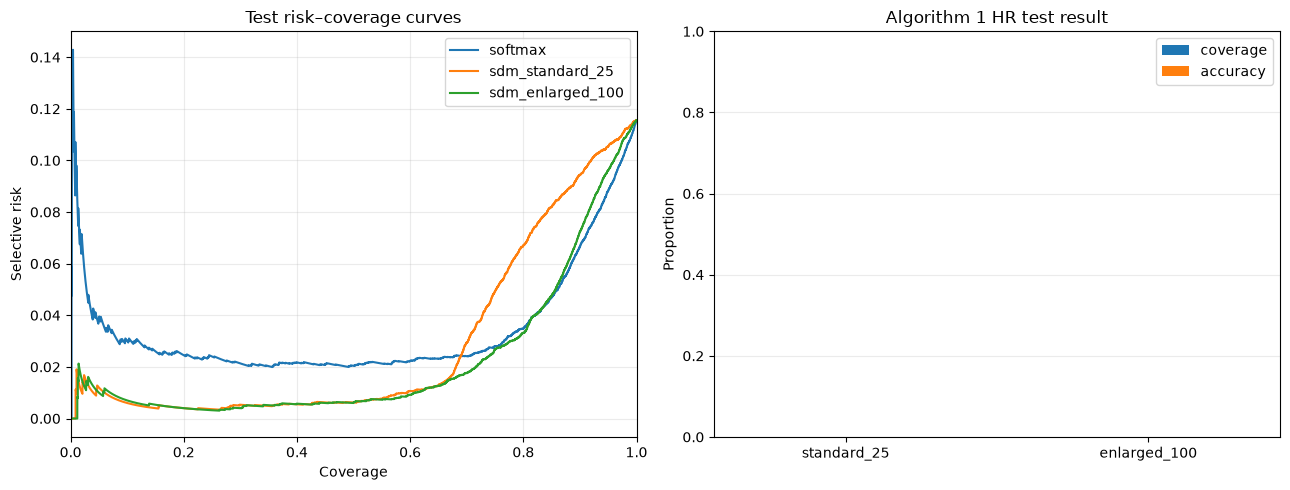

,track,region_found_on_calibration,test_admitted,test_coverage,test_accuracy_when_admitted
0,standard_25,False,0,0.0,NaN
1,enlarged_100,False,0,0.0,NaN


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for method, (coverage, risk) in curves.items():
    axes[0].plot(coverage, risk, label=method)
axes[0].set(title="Test risk–coverage curves", xlabel="Coverage", ylabel="Selective risk", xlim=(0, 1))
axes[0].grid(alpha=0.25)
axes[0].legend()

width = 0.35
x = np.arange(len(tracks))
hr_coverage = [tracks[name]["test_hr_admitted"].mean() for name in tracks]
hr_accuracy = []
for name in tracks:
    admitted = tracks[name]["test_hr_admitted"]
    hr_accuracy.append(
        (test["predictions"][admitted] == test["targets"][admitted]).mean() if admitted.any() else np.nan
    )
axes[1].bar(x - width / 2, hr_coverage, width, label="coverage")
axes[1].bar(x + width / 2, np.nan_to_num(hr_accuracy), width, label="accuracy")
axes[1].set(title="Algorithm 1 HR test result", ylabel="Proportion", xticks=x, xticklabels=list(tracks), ylim=(0, 1))
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

hr_table = pd.DataFrame({
    "track": list(tracks),
    "region_found_on_calibration": [tracks[name]["region"]["found"] for name in tracks],
    "test_admitted": [int(tracks[name]["test_hr_admitted"].sum()) for name in tracks],
    "test_coverage": hr_coverage,
    "test_accuracy_when_admitted": hr_accuracy,
})
display(hr_table)

## Low- versus high-performing class cohorts on held-out test data

Results are shown two ways. `true_class` is retrospective error analysis using the known label. `predicted_class` is deployable grouping because it uses only the model's prediction. Each track uses the cohort map frozen from its own calibration set.

In [16]:
cohort_rows = []
correct = test["predictions"] == test["targets"]
for name, track in tracks.items():
    for assignment, class_ids in {
        "true_class": test["targets"],
        "predicted_class": test["predictions"],
    }.items():
        example_cohorts = track["class_cohorts"][class_ids]
        for cohort in ("below_target", "at_or_above_target"):
            mask = example_cohorts == cohort
            if mask.any():
                admitted = track["test_hr_admitted"] & mask
                cohort_rows.append({
                    "track": name, "assignment": assignment, "cohort": cohort,
                    "examples": int(mask.sum()), "accuracy": float(correct[mask].mean()),
                    "softmax_confidence": float(test["probabilities"].max(axis=1)[mask].mean()),
                    "sdm_confidence": float(track["test_confidence"][mask].mean()),
                    "mean_q": float(test_q[mask].mean()), "mean_d": float(track["test_d"][mask].mean()),
                    "hr_coverage": float(admitted.sum() / mask.sum()),
                    "hr_accuracy": float(correct[admitted].mean()) if admitted.any() else np.nan,
                })
cohort_table = pd.DataFrame(cohort_rows)
display(cohort_table)

,track,assignment,cohort,examples,accuracy,softmax_confidence,sdm_confidence,mean_q,mean_d,hr_coverage,hr_accuracy
0,standard_25,true_class,below_target,6300,0.851429,0.836581,0.345869,301.118103,0.132628,0.0,NaN
1,standard_25,true_class,at_or_above_target,3700,0.940541,0.874968,0.578826,341.385956,0.246616,0.0,NaN
2,standard_25,predicted_class,below_target,6269,0.855639,0.836677,0.347045,300.525604,0.133141,0.0,NaN
3,standard_25,predicted_class,at_or_above_target,3731,0.932726,0.874489,0.574914,342.046906,0.244807,0.0,NaN
4,enlarged_100,true_class,below_target,7500,0.860000,0.839384,0.479163,305.382385,0.166714,0.0,NaN
5,enlarged_100,true_class,at_or_above_target,2500,0.957600,0.884986,0.770417,347.921600,0.327416,0.0,NaN
6,enlarged_100,predicted_class,below_target,7468,0.863685,0.840029,0.480933,305.607391,0.167305,0.0,NaN
7,enlarged_100,predicted_class,at_or_above_target,2532,0.945498,0.882507,0.761516,346.720367,0.323641,0.0,NaN


## Save auditable individual results and compact metric tables

The CSV has one row per test image, so each confident error and nearest exemplar can be inspected. JSON is retained only for configuration and provenance; it is not the evaluation dataset.

In [17]:
suffix = "smoke" if SMOKE else "full"
individual = pd.DataFrame({
    "test_index": np.arange(len(test["targets"])),
    "true_class_id": test["targets"],
    "true_class_name": np.asarray(test_base.classes)[test["targets"]],
    "predicted_class_id": test["predictions"],
    "predicted_class_name": np.asarray(test_base.classes)[test["predictions"]],
    "correct": correct,
    "softmax_confidence": test["probabilities"].max(axis=1),
    "q": test_q,
    "nearest_distance_squared": test_d_nearest,
    "nearest_reference_dataset_index": train_indices[test_neighbor_indices[:, 0]],
})
for name, track in tracks.items():
    individual[f"{name}_d"] = track["test_d"]
    individual[f"{name}_sdm_confidence"] = track["test_confidence"]
    individual[f"{name}_q_prime"] = track["test_q_prime"]
    individual[f"{name}_hr_admitted"] = track["test_hr_admitted"]
    individual[f"{name}_true_cohort"] = track["class_cohorts"][test["targets"]]
    individual[f"{name}_predicted_cohort"] = track["class_cohorts"][test["predictions"]]

individual_path = RUN_DIR / f"test_individual_results_{suffix}.csv.gz"
metrics_path = RUN_DIR / f"test_reliability_metrics_{suffix}.csv"
cohort_path = RUN_DIR / f"test_cohort_metrics_{suffix}.csv"
hr_path = RUN_DIR / f"test_hr_metrics_{suffix}.csv"
metadata_path = RUN_DIR / f"experiment_metadata_{suffix}.json"
individual.to_csv(individual_path, index=False, compression="gzip")
metrics_table.to_csv(metrics_path)
cohort_table.to_csv(cohort_path, index=False)
hr_table.to_csv(hr_path, index=False)

metadata = {
    "config": CONFIG,
    "upstream_sdm_commit": "06d295df31e0ab8ee13729244b9a7d4d5c4f91de",
    "variant": "frozen_identity_adaptor",
    "split_sizes": {"train_reference": 37_500, "validation": 2_500, "standard_calibration": 2_500, "enlarged_calibration": 10_000, "test": 10_000},
    "best_validation_accuracy": best_validation_accuracy,
    "fit_summary": json.loads(fit_summary.to_json(orient="records")),
    "artifacts": {"individual_results": str(individual_path), "metrics": str(metrics_path), "cohorts": str(cohort_path), "hr": str(hr_path)},
    "versions": {"python": platform.python_version(), "torch": torch.__version__, "torchvision": torchvision.__version__, "numpy": np.__version__, "pandas": pd.__version__},
}
metadata_path.write_text(json.dumps(metadata, indent=2) + "\n", encoding="utf-8")

print("Saved:")
for path in (individual_path, metrics_path, cohort_path, hr_path, metadata_path):
    print(f"  {path}")

Saved:
  /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/calibration_25_vs_100/benchmark/test_individual_results_full.csv.gz
  /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/calibration_25_vs_100/benchmark/test_reliability_metrics_full.csv
  /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/calibration_25_vs_100/benchmark/test_cohort_metrics_full.csv
  /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/calibration_25_vs_100/benchmark/test_hr_metrics_full.csv
  /home/randy/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/calibration_25_vs_100/benchmark/experiment_metadata_full.json


## How to read the comparison

- Prefer the enlarged track if it improves AURC, error-detection AUROC/AUPRC, and coverage at 95% accuracy without degrading probability metrics.
- HR accuracy is meaningless without HR coverage; zero coverage is an honest outcome when no finite 100-class region exists.
- Top-1 accuracy is identical across softmax and SDM because this activation preserves the raw-logit argmax. The scientific question is whether SDM confidence ranks errors and supports abstention better.
- A better enlarged result supports the hypothesis that 25 calibration examples/class were too sparse. A similar or worse result points toward representation/adaptor limitations rather than calibration size alone.
- Test results are final evaluation evidence. Any subsequent change to alpha, split size, adaptor, or thresholds defines a new experiment and requires a fresh held-out evaluation protocol.